# Modelo complejo

In [2]:
from importacion_preprocesado import download_and_load_data, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = download_and_load_data(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.
X shape: (4217, 128, 128, 3) y shape: (4217,)


In [3]:
# Importar la función
import sys
sys.path.append('../')

from models.complejo_cnn import create_model


# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.0001) # con learning rate de 0.001 no converje 

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Con un learning rate de 0.001, no cenverje, teniendo la validación haciendo una montaña y un accuracy de media de 0.4 en validacion, tabla de resultados: 
            Train   Val  Test

Accuracy   0.45  0.44  0.45

F1         0.34  0.34  0.34


In [ ]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100
)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 290ms/step - accuracy: 0.2914 - loss: 4.3828 - val_accuracy: 0.2263 - val_loss: 3.8334
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 237ms/step - accuracy: 0.4029 - loss: 4.0364 - val_accuracy: 0.2547 - val_loss: 3.9201
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 286ms/step - accuracy: 0.3998 - loss: 4.0392 - val_accuracy: 0.2547 - val_loss: 3.9095
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.4417 - loss: 3.9465 - val_accuracy: 0.3341 - val_loss: 3.9246
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 282ms/step - accuracy: 0.4294 - loss: 3.9462 - val_accuracy: 0.3175 - val_loss: 3.9205
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 280ms/step - accuracy: 0.4267 - loss: 3.8954 - val_accuracy: 0.2796 - val_loss: 4.2943
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 265ms/step - accuracy: 0.4488 - loss: 3.8348 - val_accuracy: 0.2986 - val_loss: 4.4922
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.4678 - loss: 3.8044 - 

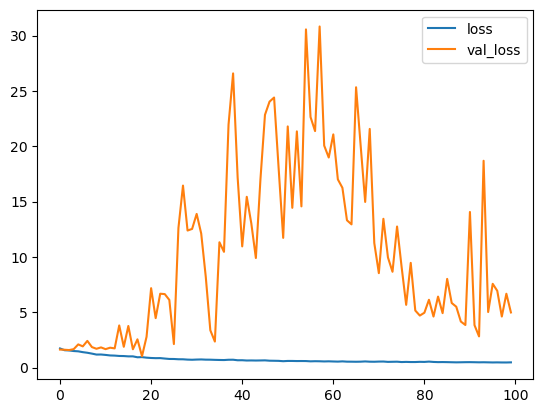

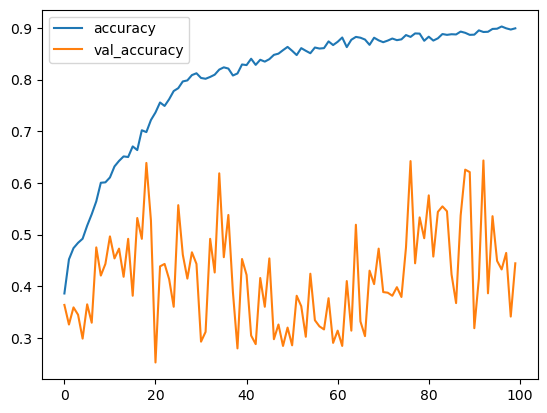

In [ ]:
import matplotlib.pyplot as plt
# Visualizacion evolucion loss durante el entrenamiento
plt.plot(hist.history['loss'],label="loss")
plt.plot(hist.history['val_loss'],label="val_loss")
plt.legend()
plt.show()

# Visualizacion de accuracy durante el entrenamiento
plt.plot(hist.history["accuracy"], label= "accuracy")
plt.plot(hist.history["val_accuracy"], label ="val_accuracy")
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 122, 122, 64)   │         9,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 122, 122, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 122, 122, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 55, 55, 64)     │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 55, 55, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 568,714 (2.17 MB)

 Trainable params: 283,204 (1.08 MB)

 Non-trainable params: 2,304 (9.00 KB)

 Optimizer params: 283,206 (1.08 MB)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)
df.round(2)


80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
          Train   Val  Test
Accuracy   0.45  0.44  0.45
F1         0.34  0.34  0.34


In [ ]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

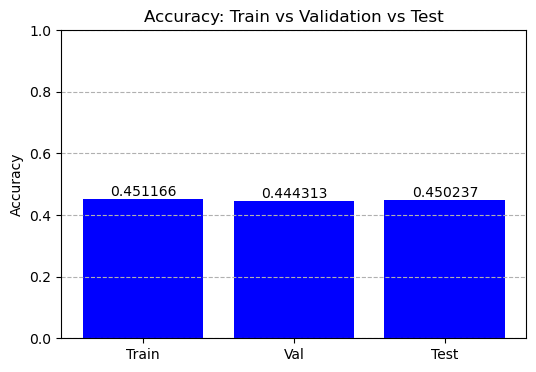

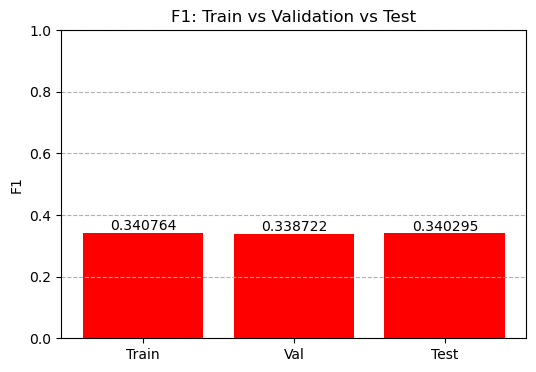

In [ ]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step


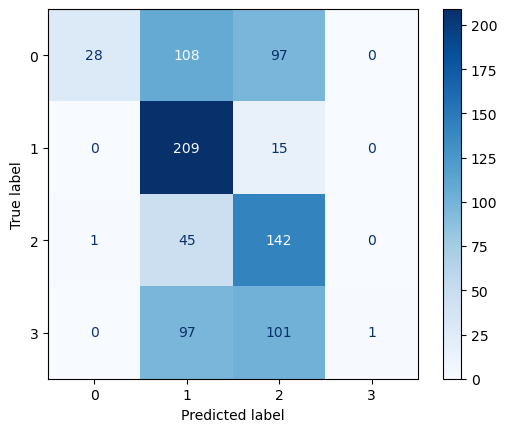

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")